# 03 — Segment Insights

Profile each RFM segment and translate the numbers into business recommendations.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

SEGMENT_COLORS = {
    'Champions':       '#2ecc71',
    'Loyal Customers': '#3498db',
    'New Customers':   '#9b59b6',
    'At Risk':         '#e67e22',
    'Lost':            '#e74c3c',
}

In [2]:
con = duckdb.connect('../data/retail.duckdb')
seg = con.execute('SELECT * FROM rfm_segments').df()
rfm = con.execute('SELECT * FROM rfm_scores').df()
con.close()

data = seg.merge(rfm[['Customer ID', 'recency', 'frequency', 'monetary']], on='Customer ID')
print(f'Total customers: {len(data):,}')
data.head()

Total customers: 5,878


,Customer ID,r_score,f_score,m_score,rfm_score,segment,recency,frequency,monetary
0,14095,1,1,1,3,Lost,722,1,2.95
1,13788,1,1,1,3,Lost,504,1,3.75
2,16738,2,1,1,4,Lost,297,1,3.75
3,14792,3,2,1,6,Lost,63,1,6.20
4,15913,1,1,1,3,Lost,533,1,6.30


## Customer and Revenue share per segment

In [3]:
summary = (
    data.groupby('segment')
    .agg(
        customers=('Customer ID', 'count'),
        total_revenue=('monetary', 'sum'),
        avg_order_value=('monetary', 'mean'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
    )
    .assign(
        pct_customers=lambda x: x['customers'] / x['customers'].sum() * 100,
        pct_revenue=lambda x: x['total_revenue'] / x['total_revenue'].sum() * 100,
    )
    .round(1)
    .sort_values('pct_revenue', ascending=False)
)

summary[['customers', 'pct_customers', 'pct_revenue', 'avg_order_value', 'avg_recency', 'avg_frequency']]

,customers,pct_customers,pct_revenue,avg_order_value,avg_recency,avg_frequency
segment,,,,,,
Champions,1345,22.9,68.8,9080.0,18.8,16.6
Loyal Customers,1473,25.1,16.3,1960.1,65.2,5.2
At Risk,708,12.0,8.8,2209.0,359.9,5.4
Lost,2064,35.1,5.4,467.7,383.8,1.3
New Customers,288,4.9,0.6,396.8,32.5,1.2


## Customer share vs Revenue share

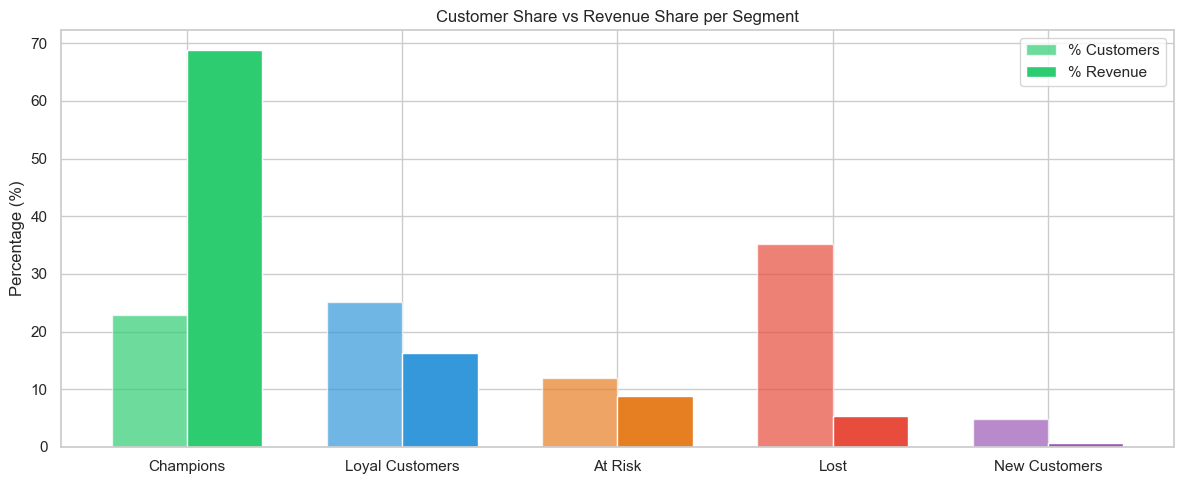

In [4]:
segments = summary.index.tolist()
colors = [SEGMENT_COLORS[s] for s in segments]

x = range(len(segments))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], summary['pct_customers'], width, label='% Customers', color=colors, alpha=0.7)
ax.bar([i + width/2 for i in x], summary['pct_revenue'],   width, label='% Revenue',   color=colors, alpha=1.0)

ax.set_xticks(list(x))
ax.set_xticklabels(segments)
ax.set_ylabel('Percentage (%)')
ax.set_title('Customer Share vs Revenue Share per Segment')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/segment_share.png', dpi=150)
plt.show()

## RFM score distribution per segment

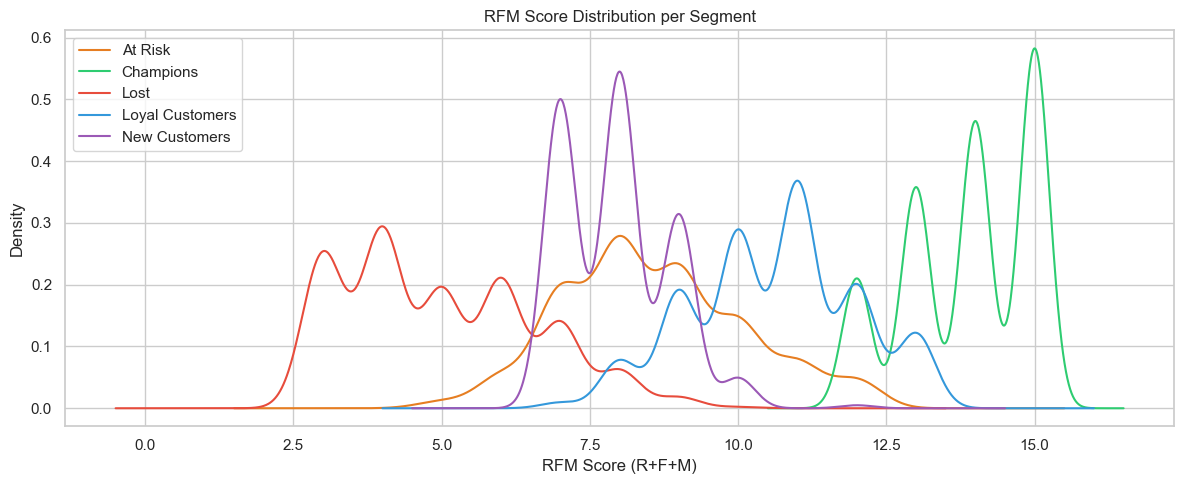

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for segment, group in data.groupby('segment'):
    group['rfm_score'].plot.kde(ax=ax, label=segment, color=SEGMENT_COLORS[segment])

ax.set_title('RFM Score Distribution per Segment')
ax.set_xlabel('RFM Score (R+F+M)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/rfm_score_distribution.png', dpi=150)
plt.show()

## Business recommendations

In [6]:
recommendations = {
    'Champions':       'Priority retention — exclusive benefits, loyalty rewards, early product access.',
    'Loyal Customers': 'Upsell — bundle offers and cross-category recommendations.',
    'New Customers':   'Nurture flow — onboarding sequence and second-purchase incentive.',
    'At Risk':         'Re-engagement — personalized win-back with time-limited incentives.',
    'Lost':            'Cost-benefit analysis before investing in win-back. Deprioritize low-monetary.',
}

print(f'{"Segment":<20} {"Customers":>10} {"% Revenue":>10}  Strategy')
print('-' * 90)
for seg_name in summary.index:
    row = summary.loc[seg_name]
    print(f'{seg_name:<20} {int(row["customers"]):>10,} {row["pct_revenue"]:>9.1f}%  {recommendations[seg_name]}')

Segment               Customers  % Revenue  Strategy
------------------------------------------------------------------------------------------
Champions                 1,345      68.8%  Priority retention — exclusive benefits, loyalty rewards, early product access.
Loyal Customers           1,473      16.3%  Upsell — bundle offers and cross-category recommendations.
At Risk                     708       8.8%  Re-engagement — personalized win-back with time-limited incentives.
Lost                      2,064       5.4%  Cost-benefit analysis before investing in win-back. Deprioritize low-monetary.
New Customers               288       0.6%  Nurture flow — onboarding sequence and second-purchase incentive.
